# Day 4 — Modelling the Fourth Dimension: RNNs & LSTMs

The world is full of **sequences**: speech, sensor readings, stock prices, heartbeats, text, music.
In all of them, *order matters* — "dog bites man" and "man bites dog" contain the same words, and
today's sensor reading only makes sense in the context of yesterday's.

Our networks so far can't handle this:

- An **MLP** needs a fixed-size input and treats every input dimension independently — shuffle the
  time steps and it wouldn't notice.
- A **CNN** detects local patterns (and 1D convolutions *are* used on time series!), but it has a
  fixed receptive field — it can't remember something that happened 500 steps ago.

**Recurrent Neural Networks (RNNs)** are built differently: they read a sequence *one step at a
time*, carrying a **memory** (the *hidden state*) from each step to the next.

Today you will:

1. Understand the **recurrence**: how a hidden state gives a network memory
2. Master the **shapes**: `(batch, sequence, features)` and friends
3. Build an RNN that **forecasts a time series**
4. See *why* vanilla RNNs forget, and how **LSTMs** fix it with gates
5. Compare RNN vs LSTM on a long-memory problem
6. Map the landscape of sequence tasks — and peek at what replaced RNNs in NLP

---

## The Core Idea: A Loop With Memory

A feed-forward layer computes `output = f(input)`. A recurrent layer computes, at every time step $t$:

$$h_t = \tanh(W_{x} x_t + W_{h} h_{t-1} + b)$$

The hidden state $h_t$ is a summary of *everything the network has seen so far*. The same weights
$W_x, W_h$ are reused at every step (just like a CNN reuses its filters at every position!) — so an
RNN can process sequences of *any* length with a fixed number of parameters.

<div style="text-align: center"><img src="rnn_vs_mlp.png" width="900"/></div>

You can picture the network "unrolled" over time:

<div style="text-align: center"><img src="unrolled_rnn.png" width="900"/></div>

_Images Sourced from: [Josh Stramer - YouTube](https://www.youtube.com/watch?v=AsNTP8Kwu80&list=PLblh5JKOoLUIxGDQs4LFFD--41Vzf-ME1&index=17)_

Crucially, training still works exactly as on Days 1–3: forward pass, loss, `backward()`, step.
Backpropagation simply flows *backwards through time* along the unrolled chain.

## A Sequence Problem: Forecasting

Our task for today: given the last `window` values of a signal, **predict the next value**.
This is one-step forecasting — the same setup used for demand prediction, sensor monitoring and
(tomorrow!) anomaly detection.



In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


We'll start with a noisy sine wave, the "MNIST of time series": simple enough to train in seconds,
real enough to show every concept.

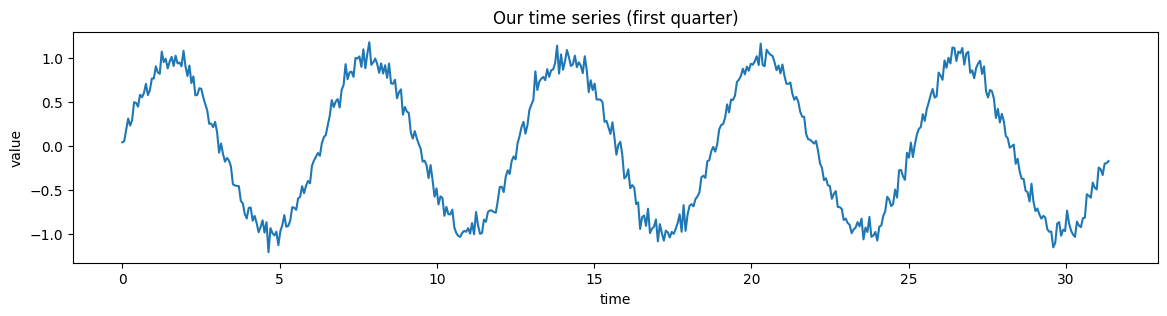

In [2]:
# A noisy periodic signal
t = np.linspace(0, 125.6, 2000)               # ~20 full periods
series = np.sin(t) + 0.08 * np.random.randn(len(t))

plt.figure(figsize=(14, 3))
plt.plot(t[:500], series[:500])
plt.title('Our time series (first quarter)')
plt.xlabel('time'); plt.ylabel('value')
plt.show()

In [3]:
# Slice the series into (input window -> next value) training pairs.
# This "sliding window" is the standard way to turn a time series into a supervised dataset.
def make_windows(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i : i + window])
        y.append(series[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

window = 50
X, y = make_windows(series, window)
print('X shape:', X.shape, ' y shape:', y.shape)   # (1950, 50), (1950,)

# chronological split: NEVER shuffle before splitting a time series,
# or your model will be "predicting" the past from the future!
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# RNNs in PyTorch (with batch_first=True) expect input of shape (batch, seq_len, features).
# Our series has a single feature per time step, so we add a final dimension of size 1.
X_train_t = torch.from_numpy(X_train).unsqueeze(-1)   # (N, 50, 1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)   # (N, 1)
X_test_t  = torch.from_numpy(X_test).unsqueeze(-1)
y_test_t  = torch.from_numpy(y_test).unsqueeze(-1)
print('X_train_t shape:', X_train_t.shape)

X shape: (1950, 50)  y shape: (1950,)
X_train_t shape: torch.Size([1560, 50, 1])


## A Familiar Tool from Day 3: 1D Convolutions

Yesterday we slid small **2D filters across an image** to pick up local spatial patterns — edges,
textures, shapes. A time series is just a **1D** signal, and the very same trick applies: slide a small
filter **along the time axis** to detect local *temporal* patterns — a rise, a dip, a spike, a
particular little wiggle. That's a **1-D convolution** (`nn.Conv1d`), and a stack of them with a linear
head makes a perfectly good forecaster.

So before reaching for anything new, let's check: can the convolutions you *already* know handle a
sequence? (Shape note: `Conv1d` wants `(batch, channels, length)` — here our single feature is the lone
"channel" and time is the "length".)

Let's create a training function.

In [4]:
# A reusable training function (same pattern as Day 2/3) — we'll use it for the CNN, the RNN AND the
# LSTM today. MSE loss, because forecasting a continuous value is a regression problem.
def train_forecaster(model, X_train, y_train, X_val, y_val, num_epochs=30, lr=0.005,
                     batch_size=64, verbose=True):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    history = dict(train=[], val=[])
    for epoch in range(num_epochs):
        model.train()
        ts = time.time()
        train_losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # standard for recurrent nets
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val.to(device)), y_val.to(device)).item()
        history['train'].append(np.mean(train_losses))
        history['val'].append(val_loss)
        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d} | train: {history['train'][-1]:.5f} "
                  f"| val: {val_loss:.5f} | {time.time()-ts:.1f}s")
    return model.eval(), history

Then create our CNN and train it.

Epoch  5 | train: 0.00988 | val: 0.00915 | 0.1s
Epoch 10 | train: 0.00864 | val: 0.00984 | 0.1s
Epoch 15 | train: 0.00801 | val: 0.00829 | 0.2s
Epoch 20 | train: 0.00767 | val: 0.00710 | 0.1s
Epoch 25 | train: 0.00776 | val: 0.00747 | 0.1s
Epoch 30 | train: 0.01199 | val: 0.01219 | 0.1s


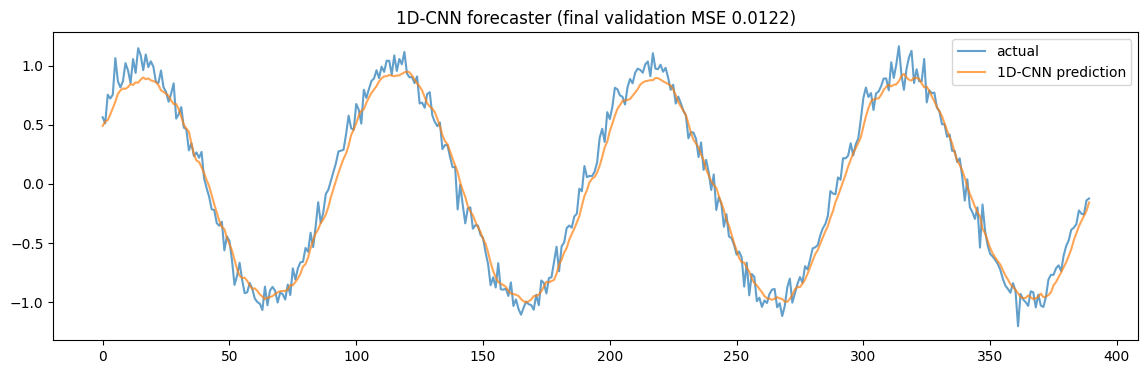

In [ ]:
class CNNForecaster(nn.Module):
    """A 1-D CNN forecaster: learnable filters slide along the TIME axis (just like Day 3's filters
    slid across an image), then a linear layer reads off the next value."""
    def __init__(self, channels=32, kernel_size=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel_size, padding=kernel_size // 2), nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),         # squeeze the time axis down to one summary per channel
        )
        self.fc = nn.Linear(channels, 1)

    def forward(self, x):                    # x: (batch, seq_len, 1)
        x = x.transpose(1, 2)                # -> (batch, 1, seq_len): Conv1d wants (batch, channels, length)
        x = self.net(x).squeeze(-1)          # -> (batch, channels)
        return self.fc(x)                    # -> (batch, 1)


torch.manual_seed(42)
cnn_model, cnn_history = train_forecaster(CNNForecaster(), X_train_t, y_train_t,
                                          X_test_t, y_test_t, num_epochs=30)

cnn_model.eval()
with torch.no_grad():
    cnn_preds = cnn_model(X_test_t.to(device)).cpu().numpy().flatten()
plt.figure(figsize=(14, 4))
plt.plot(y_test, label='actual', alpha=0.7)
plt.plot(cnn_preds, label='1D-CNN prediction', alpha=0.7)
plt.legend(); plt.title(f'1D-CNN forecaster (final validation MSE {cnn_history["val"][-1]:.4f})')
plt.show()

It works — a 1-D CNN forecasts the next value just fine. But notice its blind spot: each filter only
ever looks at `kernel_size` neighbouring steps. Stacking layers widens this **receptive field**, but it
stays **fixed and bounded** — a CNN can't, even in principle, remember something from *arbitrarily* far
back. For signals where the next value depends on context from long ago, we want a model that carries a
running **memory** through time. That's exactly what **recurrent networks** do.

## Getting the Shapes Right

Shape errors are *the* classic RNN frustration, so let's nail them before building anything.
With `batch_first=True`, `nn.RNN` takes `(batch, seq_len, input_size)` and returns **two** things:

- `output`: the hidden state at **every** time step — `(batch, seq_len, hidden_size)`
- `h_n`: the **final** hidden state only — `(num_layers, batch, hidden_size)`

For forecasting we usually want the memory after reading the whole window, i.e. the last time step.

In [ ]:
rnn = nn.RNN(input_size=1, hidden_size=16, num_layers=1, batch_first=True)

dummy = torch.randn(8, 50, 1)         # batch of 8 sequences, 50 steps, 1 feature
output, h_n = rnn(dummy)

print('input  :', dummy.shape)
print('output :', output.shape)        # (8, 50, 16) - 16 hidden state vectors at every step
print('h_n    :', h_n.shape)           # (1, 8, 16)  - final hidden state for all the sequences in the batch
print()
# the last "slice" of output is the same as h_n:
print('output[:, -1, :] == h_n[0] ->', torch.allclose(output[:, -1, :], h_n[0]))

input  : torch.Size([8, 50, 1])
output : torch.Size([8, 50, 16])
h_n    : torch.Size([1, 8, 16])

output[:, -1, :] == h_n[0] -> True


### What does `num_layers` do?

`num_layers` **stacks** recurrent layers on top of each other to make the network *deeper* — exactly like adding hidden layers to an MLP (Day 1). With `num_layers=2`, a second RNN sits on top of the first and reads its per-step memory as *its* input. Lower layers pick up short, fine-grained patterns; higher layers compose them into longer, more abstract ones.

Don't confuse it with the **sequence length**: `num_layers` is *depth* (stacked layers, each with its own weights), while the 50 time steps are the *same* layer applied 50 times. A 50-step input is **not** a 50-layer network.

This is also the leading dimension of `h_n`: shape `(num_layers, batch, hidden_size)` holds the final memory of *each* layer (`output` only ever shows the top layer).

More layers = more capacity but more parameters and overfitting risk, so for simple forecasting **`num_layers=1` is plenty**. (When you do stack them, pass `dropout=...` to regularise *between* layers.)

## Building the Forecaster

The model is beautifully small: a recurrent layer to read the window, then a single linear layer that
maps the final hidden state to the predicted next value. We make the cell type a parameter so the
*same* class can use `nn.RNN`, `nn.LSTM` or `nn.GRU` — they all share this interface.

In [7]:
class Forecaster(nn.Module):
    def __init__(self, cell=nn.RNN, hidden_size=32):
        super().__init__()
        self.rnn = cell(input_size=1, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.rnn(x)            # works for RNN, LSTM and GRU alike
        return self.fc(output[:, -1, :])   # predict from the final hidden state


# we train it with the SAME `train_forecaster` we wrote for the 1-D CNN above

Epoch  5 | train: 0.01093 | val: 0.01121 | 0.7s
Epoch 10 | train: 0.00983 | val: 0.00837 | 0.7s
Epoch 15 | train: 0.00971 | val: 0.00877 | 0.7s
Epoch 20 | train: 0.00922 | val: 0.00968 | 0.7s
Epoch 25 | train: 0.00856 | val: 0.00978 | 0.7s
Epoch 30 | train: 0.00857 | val: 0.00764 | 0.7s


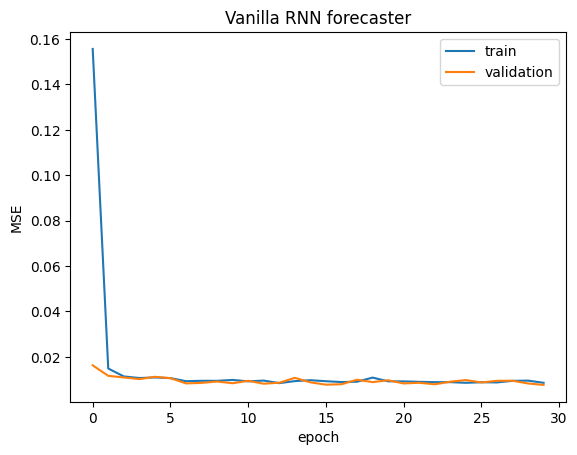

In [8]:
torch.manual_seed(42)
rnn_model, rnn_history = train_forecaster(Forecaster(cell=nn.RNN), X_train_t, y_train_t,
                                          X_test_t, y_test_t)

plt.plot(rnn_history['train'], label='train')
plt.plot(rnn_history['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.title('Vanilla RNN forecaster')
plt.show()

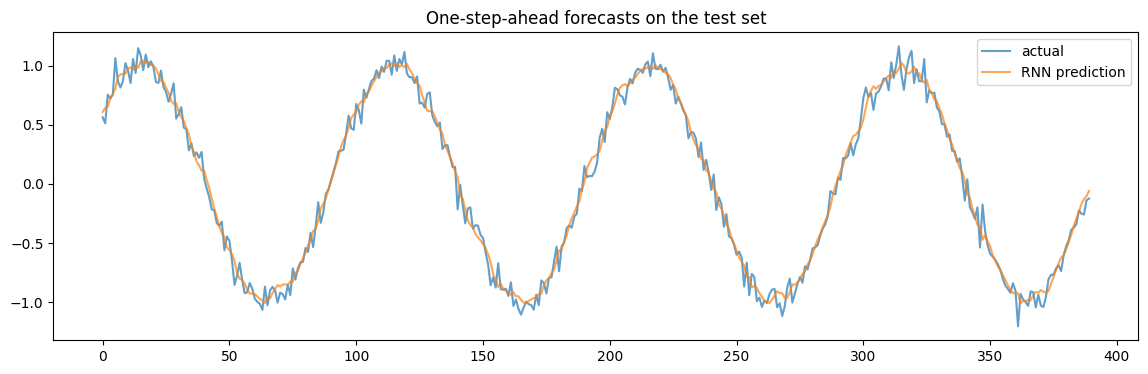

In [9]:
# How do the forecasts look? Predict one step ahead across the whole test set.
rnn_model.eval()
with torch.no_grad():
    preds = rnn_model(X_test_t.to(device)).cpu().numpy().flatten()

plt.figure(figsize=(14, 4))
plt.plot(y_test, label='actual', alpha=0.7)
plt.plot(preds, label='RNN prediction', alpha=0.7)
plt.legend(); plt.title('One-step-ahead forecasts on the test set')
plt.show()

Not bad at all for ~30 seconds of training! But our sine wave is an easy customer: everything you need
to predict the next value happened in the last few steps.

---

# The Problem: RNNs Forget

Remember the **vanishing gradient problem** from Days 1–2? Deep networks with sigmoid/tanh squash
gradients layer after layer until the early layers learn nothing.

An RNN unrolled over 200 time steps **is** a 200-layer-deep network with a `tanh` at every layer —
and the *same* weight matrix multiplied in at every step. Gradients flowing backwards through time
shrink (or blow up) exponentially. The practical consequence:

> **Vanilla RNNs can't connect information across long time gaps.** They live in the moment.

## The Fix: Long Short-Term Memory (LSTM)

The LSTM (Hochreiter & Schmidhuber, 1997) adds a second channel of memory: the **cell state** $C_t$ —
a "conveyor belt" running straight through time with only *element-wise* operations on it, so
gradients can flow across hundreds of steps undisturbed. Three learned **gates** (each a sigmoid
layer outputting values in 0–1) control the belt:

| Gate | Question it answers |
|---|---|
| **Forget gate** $f_t$ | What old memory should we erase? |
| **Input gate** $i_t$ | What new information should we store? |
| **Output gate** $o_t$ | What part of the memory should we reveal as $h_t$? |

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \qquad h_t = o_t \odot \tanh(C_t)$$

<div style="text-align: center"><img src="lstm.png" width="900"/></div>

The key insight: memory persistence is **learned**, not hard-wired. The network itself decides what
to remember for 500 steps and what to discard immediately.

(The **GRU** is a popular simplification with two gates instead of three — usually similar
performance, slightly cheaper.)

<div style="text-align: center"><img src="lstm_roll.png" width="900"/></div>

In PyTorch the only API difference is that an LSTM carries *two* states, `(h_n, c_n)`:

In [10]:
lstm = nn.LSTM(input_size=1, hidden_size=16, num_layers=1, batch_first=True)

output, (h_n, c_n) = lstm(dummy)      # note: a tuple of (hidden state, cell state)

print('output :', output.shape)        # (8, 50, 16) - same as the RNN
print('h_n    :', h_n.shape)           # (1, 8, 16)
print('c_n    :', c_n.shape)           # (1, 8, 16) - the cell state ("conveyor belt")

output : torch.Size([8, 50, 16])
h_n    : torch.Size([1, 8, 16])
c_n    : torch.Size([1, 8, 16])


## Showdown: RNN vs LSTM — Does Memory Help Here?

In theory the LSTM should shine when the *distant* past matters. So let's make the task harder: add a
slow trend riding underneath the fast wave, and lengthen the window. Intuitively, to predict well the
model now has to track where it is in the *slow* cycle across the whole window — surely the LSTM's
memory wins? Let's actually measure it.

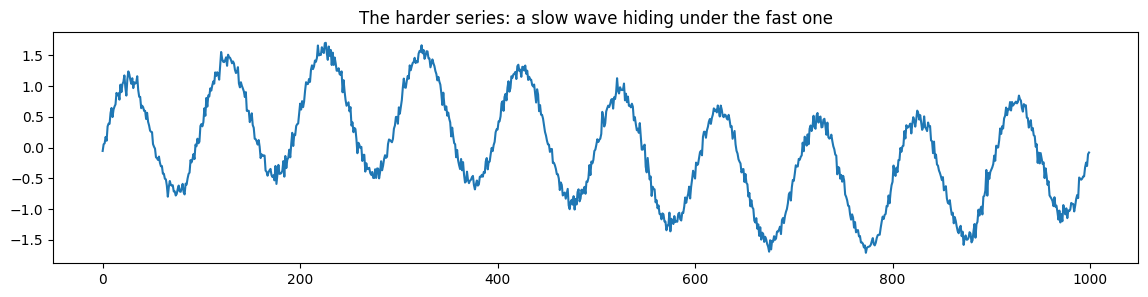

In [11]:
# fast wave + a slow trend underneath + noise
series_hard = np.sin(t) + 0.6 * np.sin(0.1 * t) + 0.08 * np.random.randn(len(t))

window_hard = 120
Xh, yh = make_windows(series_hard, window_hard)
split = int(0.8 * len(Xh))
Xh_train = torch.from_numpy(Xh[:split]).unsqueeze(-1)
yh_train = torch.from_numpy(yh[:split]).unsqueeze(-1)
Xh_test  = torch.from_numpy(Xh[split:]).unsqueeze(-1)
yh_test  = torch.from_numpy(yh[split:]).unsqueeze(-1)

plt.figure(figsize=(14, 3))
plt.plot(series_hard[:1000])
plt.title('The harder series: a slow wave hiding under the fast one')
plt.show()

RNN:  final validation MSE = 0.00947
LSTM:  final validation MSE = 0.00862


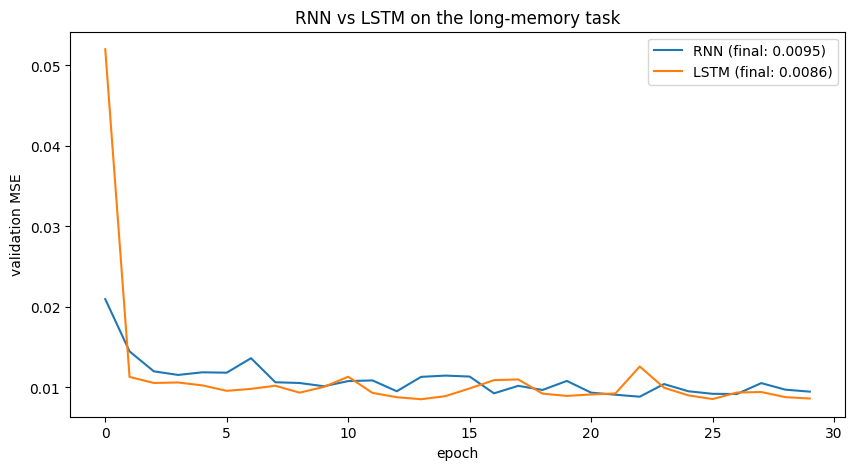

In [12]:
results = {}
for name, cell in [('RNN', nn.RNN), ('LSTM', nn.LSTM)]:
    torch.manual_seed(42)
    model, hist = train_forecaster(Forecaster(cell=cell), Xh_train, yh_train,
                                   Xh_test, yh_test, num_epochs=30, verbose=False)
    results[name] = (model, hist)
    print(f'{name}:  final validation MSE = {hist["val"][-1]:.5f}')

plt.figure(figsize=(10, 5))
for name, (_, hist) in results.items():
    plt.plot(hist['val'], label=f'{name} (final: {hist["val"][-1]:.4f})')
plt.xlabel('epoch'); plt.ylabel('validation MSE'); plt.legend()
plt.title('RNN vs LSTM on the long-memory task')
plt.show()

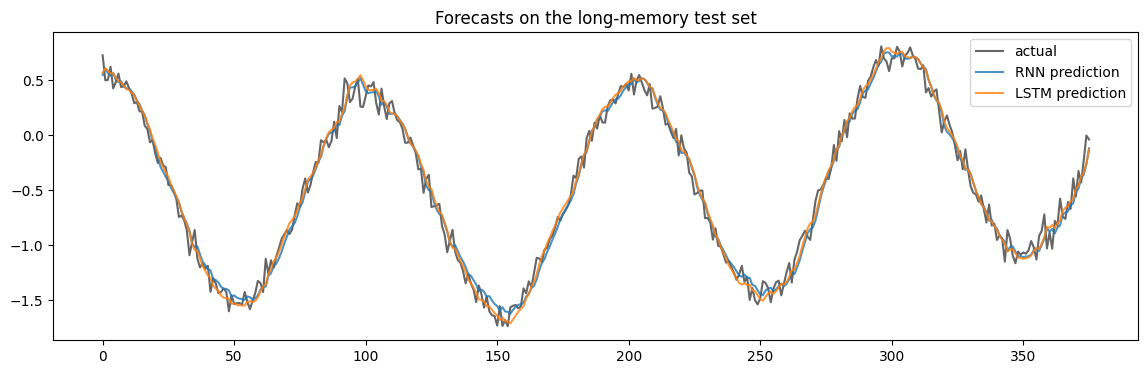

In [13]:
# Compare the actual forecasts
plt.figure(figsize=(14, 4))
plt.plot(yh[split:], label='actual', color='black', alpha=0.6)
for name, (model, _) in results.items():
    with torch.no_grad():
        preds = model(Xh_test.to(device)).cpu().numpy().flatten()
    plt.plot(preds, label=f'{name} prediction', alpha=0.8)
plt.legend(); plt.title('Forecasts on the long-memory test set')
plt.show()

**The surprise:** they come out nearly tied — the LSTM's fabled memory barely helped.

Why? Because **one-step forecasting of a smooth signal is dominated by recent context.** To guess the
next value of a wave, the last handful of steps already pin down the phase, so being able to recall
something 100 steps back adds almost nothing. The slow trend *is* there, but it drifts so gradually
that the recent values already capture it. A model only *needs* long memory when the answer depends on
the distant past in a way the recent past doesn't reveal — and this task simply isn't like that.

Does *real-world* data behave any differently? Let's find out.

## Does Real Data Change the Story? ⚡ PJM Electricity Demand

That was a synthetic signal. Maybe real data — with its messy mix of daily routines, weekday/weekend
swings, weather and holidays — gives the LSTM's memory more to chew on? Let's test on a genuine
benchmark: **PJM hourly electricity demand** (`PJME_hourly.csv`), megawatts drawn every hour across a
large US grid region for over a decade.

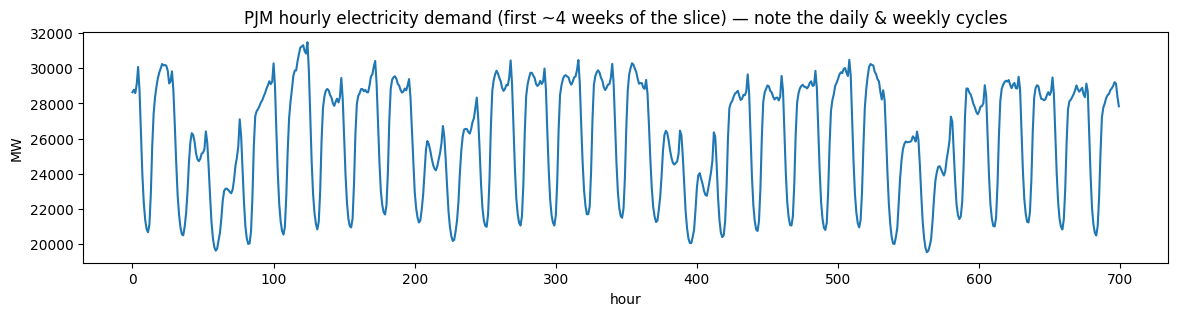

In [14]:
import pandas as pd

# load, sort chronologically, and take a recent ~2-year slice (for speed)
pjm = pd.read_csv('PJME_hourly.csv', parse_dates=['Datetime']).sort_values('Datetime')
demand = pjm['PJME_MW'].values.astype(np.float32)[-20000:]

# normalise using TRAIN statistics only (never peek at the future)
cut = int(0.8 * len(demand))
mu, sd = demand[:cut].mean(), demand[:cut].std()
demand_norm = (demand - mu) / sd

plt.figure(figsize=(14, 3))
plt.plot(demand[:700])
plt.title('PJM hourly electricity demand (first ~4 weeks of the slice) — note the daily & weekly cycles')
plt.xlabel('hour'); plt.ylabel('MW')
plt.show()

RNN:  final validation MSE = 0.00238
LSTM:  final validation MSE = 0.00219


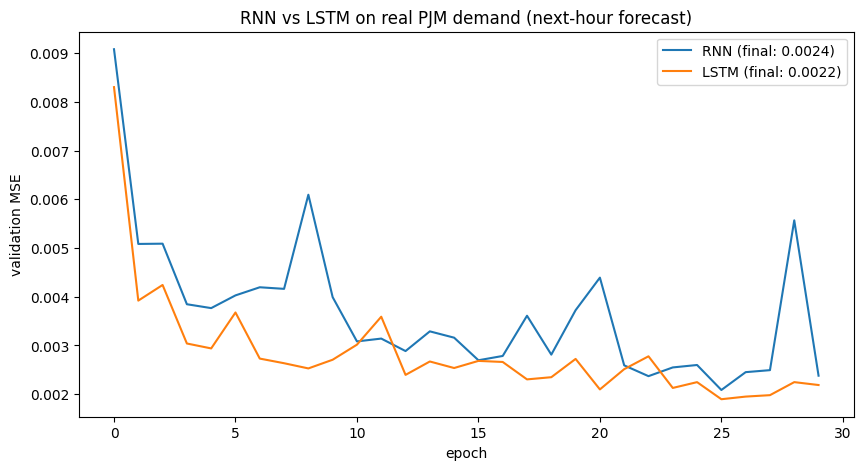

In [15]:
# window it exactly like before — predict the NEXT hour from the previous 48
pjm_window = 48
Xp, yp = make_windows(demand_norm, pjm_window)
sp = int(0.8 * len(Xp))
Xp_train = torch.from_numpy(Xp[:sp]).unsqueeze(-1); yp_train = torch.from_numpy(yp[:sp]).unsqueeze(-1)
Xp_test  = torch.from_numpy(Xp[sp:]).unsqueeze(-1); yp_test  = torch.from_numpy(yp[sp:]).unsqueeze(-1)

pjm_results = {}
for name, cell in [('RNN', nn.RNN), ('LSTM', nn.LSTM)]:
    torch.manual_seed(42)
    model, hist = train_forecaster(Forecaster(cell=cell), Xp_train, yp_train,
                                   Xp_test, yp_test, num_epochs=30, verbose=False)
    pjm_results[name] = (model, hist)
    print(f'{name}:  final validation MSE = {hist["val"][-1]:.5f}')

plt.figure(figsize=(10, 5))
for name, (_, hist) in pjm_results.items():
    plt.plot(hist['val'], label=f'{name} (final: {hist["val"][-1]:.4f})')
plt.xlabel('epoch'); plt.ylabel('validation MSE'); plt.legend()
plt.title('RNN vs LSTM on real PJM demand (next-hour forecast)')
plt.show()

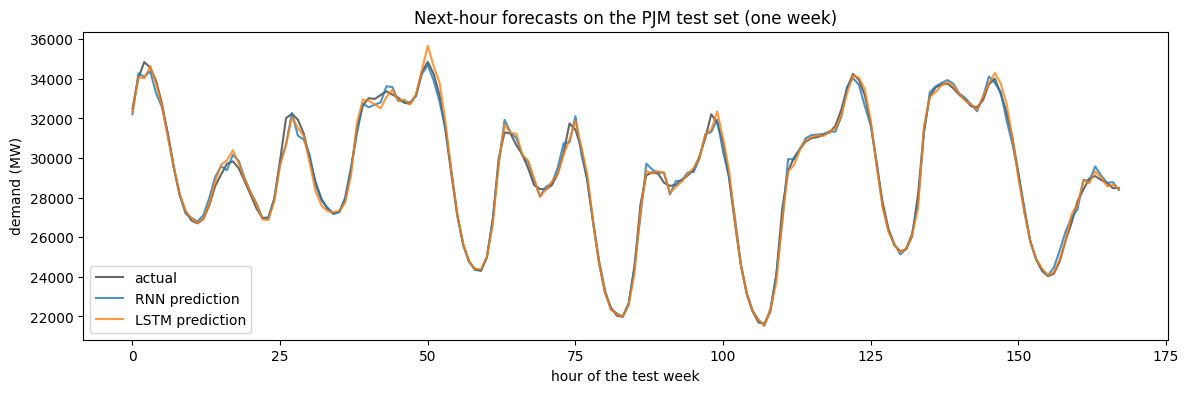

In [16]:
# Compare the actual forecasts (one week of the test set, converted back to real megawatts)
hours = 24 * 7
plt.figure(figsize=(14, 4))
plt.plot(yp_test.numpy().flatten()[:hours] * sd + mu, label='actual', color='black', alpha=0.6)
for name, (model, _) in pjm_results.items():
    model.eval()
    with torch.no_grad():
        preds = model(Xp_test.to(device)).cpu().numpy().flatten()[:hours] * sd + mu
    plt.plot(preds, label=f'{name} prediction', alpha=0.8)
plt.xlabel('hour of the test week'); plt.ylabel('demand (MW)'); plt.legend()
plt.title('Next-hour forecasts on the PJM test set (one week)')
plt.show()

**Same verdict.** On real hourly demand, predicting one hour ahead, the RNN and LSTM land neck-and-neck
again — because next hour's demand is overwhelmingly set by the last few hours. (Push the horizon out to
a full *day* ahead and the task gets dramatically harder for *both* — the errors balloon — yet the two
still stay close.)

So when *does* the LSTM's memory actually earn its keep? When the answer genuinely depends on
information from **far back that the recent steps don't reveal** — the long-range dependencies in
**language** (a pronoun pointing to a noun many words earlier), tasks with long gaps between cause and
effect, or very long sequences where a vanilla RNN's gradients vanish. On *locally predictable* signals
like these, a plain RNN keeps right up — and knowing *that* saves you from reaching for a heavier model
when a simpler one will do. **The LSTM is insurance for when long memory is truly needed, not a free win
on every sequence.**

---

# The Sequence Modelling Landscape

What we built today (sequence in → one value out) is just one shape of sequence problem:

| Pattern | Input → Output | Example |
|---|---|---|
| many-to-one | sequence → value/class | today's forecaster; sentiment analysis; fault classification |
| one-to-many | value → sequence | image captioning; music generation from a seed |
| many-to-many (aligned) | sequence → sequence, same length | tagging each word; per-timestep anomaly scores |
| many-to-many (encoder–decoder) | sequence → different sequence | translation; speech-to-text; **autoencoders (tomorrow!)** |

Other tools you now have the foundations to pick up quickly:

- **Stacked recurrent layers**: feed one LSTM's per-step outputs into another
  (`num_layers=2`, or chain separate `nn.LSTM` modules — see the extras notebook)
- **Multivariate inputs**: several sensors per time step? Just set `input_size=n_features` —
  tomorrow's capstone does exactly this
- **Bidirectional LSTMs**: read the sequence both ways when the "future" is available (e.g. offline text)
- **1D CNNs for sequences**: convolution works on time too (we built one at the *start* of today!),
  and CNN + LSTM hybrids are common (see `extras/` tomorrow)
- **Hybrid RNN types**: you don't have to use one or the other, using different combinations can lead to different results. See [this paper](https://www.sciencedirect.com/science/article/pii/S2215016125003073) on such examples combining, RNNs, GRUs and LSTMs

### What about text? And where did all the RNNs go?

Text becomes a sequence of vectors via **embeddings** (each word/token → a learned vector), after
which everything above applies. But modern NLP has largely replaced recurrence with the
**Transformer**, which uses *attention* to look at all positions at once — no memory bottleneck, and
massively parallel to train. That's the architecture behind GPT, BERT and friends ("GPT" = Generative
Pretrained *Transformer*). For *streaming* signals, on-device models, and many time-series problems,
however, LSTMs remain a strong, efficient and widely deployed choice — and that's exactly where we
put them to work tomorrow.

---

# Day 4 Recap & Exercises

**What you learned today:** recurrence and hidden state, RNN/LSTM shapes, sliding-window forecasting,
why vanilla RNNs forget, how LSTM gates fix it, and the map of sequence tasks.

### Exercises

1. **GRU joins the race.** Add `nn.GRU` to the showdown. Where does it land between RNN and LSTM —
   in accuracy and in training time?
2. **Window study.** For the hard series, train LSTMs with `window` = 20, 60, 120, 240. Plot final
   validation MSE vs window length. Where does more context stop helping?
3. **Multi-step forecasting.** Predict 10 steps ahead instead of 1: feed each prediction back in as
   input and repeat ("autoregressive" forecasting). How fast do errors compound?
4. **Go multivariate.** Stack the easy and hard series into a 2-feature input (`input_size=2`) and
   predict both next values. (This is a warm-up for tomorrow.)
5. **(Stretch)** Download a real series (daily temperatures, electricity load...) and forecast it.
   Remember Day 2: normalise your inputs!

### Tomorrow: Day 5 — The Capstone

You now know LSTMs (today) and encoder–decoder structures (the taxonomy above). Tomorrow we fuse them
into an **LSTM autoencoder** that learns what "normal" looks like from data alone — and flags
anomalies no one explicitly taught it to recognise. You'll leave with a complete project you can
show off.